In [19]:
# EMERGENCY DEPARTMENT DEMAN FORECASTING INVESTIGATION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [20]:
# load data
BASE_DIR = Path.cwd().parent
RAW_DATA_DIR = BASE_DIR / "data" / "raw"

ED_VISITS_FILE = RAW_DATA_DIR / "ed_visits.csv"

ed = pd.read_csv(ED_VISITS_FILE)

print("ED visits:", ed.shape)
display(ed.head())

ED visits: (6000, 22)


,ed_visit_id,patient_id,arrival_datetime,departure_datetime,triage_level,triage_category,chief_complaint,day_of_week,hour_of_arrival,month,...,door_to_doctor_min,ed_los_minutes,imaging_ordered,labs_ordered,iv_access,disposition,admitted_from_ed,left_ama,attending_ed_md,hospital
0,ED-0000001,PAT-004656,2022-11-07 00:00,2022-11-07 09:21,3,Urgent,Drug overdose,Monday,0,11,...,172,561,0,1,1,Admitted,0,0,ED-MD-10,MHN Boston General
1,ED-0000002,PAT-004065,2024-06-23 00:00,2024-06-23 02:45,1,Resuscitation,Leg swelling,Sunday,0,6,...,28,165,1,0,0,Discharged Home,1,0,ED-MD-40,MHN Boston General
2,ED-0000003,PAT-003922,2020-12-07 00:00,2020-12-07 06:25,5,Non-Urgent,Hypertensive urgency,Monday,0,12,...,11,385,0,1,0,Discharged Home,1,0,ED-MD-33,MHN Roxbury Community
3,ED-0000004,PAT-001788,2020-12-14 00:00,2020-12-14 04:07,4,Less Urgent,Leg swelling,Monday,0,12,...,5,247,0,0,1,Discharged Home,0,0,ED-MD-36,MHN Boston General
4,ED-0000005,PAT-004741,2021-08-19 00:00,2021-08-19 01:35,3,Urgent,Altered mental status,Thursday,0,8,...,65,95,0,1,1,Admitted,0,0,ED-MD-25,MHN Jamaica Plain


In [21]:
# Convert dates

ed["arrival_datetime"] = pd.to_datetime(ed["arrival_datetime"], errors="coerce")

In [22]:
# Create valid date features

ed["arrival_date"] = ed["arrival_datetime"].dt.date
ed["year"] = ed["arrival_datetime"].dt.year
ed["month"] = ed["arrival_datetime"].dt.month
ed["day"] = ed["arrival_datetime"].dt.day

# Keep existing day_of_week column because it is already valid text
ed["is_weekend"] = ed["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

In [23]:
# Daily ED demand

ed["arrival_date"] = ed["arrival_datetime"].dt.date

ed_daily = ed.groupby("arrival_date").agg(
    ed_arrivals=("ed_visit_id", "count"),
    avg_wait_time=("wait_time_minutes", "mean"),
    avg_door_to_doctor=("door_to_doctor_min", "mean"),
    avg_ed_los=("ed_los_minutes", "mean"),
    admissions_from_ed=("admitted_from_ed", "sum")
).reset_index()

ed_daily["avg_wait_time"] = ed_daily["avg_wait_time"].round(1)
ed_daily["avg_door_to_doctor"] = ed_daily["avg_door_to_doctor"].round(1)
ed_daily["avg_ed_los"] = ed_daily["avg_ed_los"].round(1)

display(ed_daily.head())

,arrival_date,ed_arrivals,avg_wait_time,avg_door_to_doctor,avg_ed_los,admissions_from_ed
0,2020-01-01,2,102.0,102.0,291.0,1
1,2020-01-02,2,31.0,31.0,390.5,1
2,2020-01-03,3,123.3,123.3,333.0,0
3,2020-01-04,3,45.7,45.7,255.7,1
4,2020-01-05,2,71.0,73.5,362.0,0


In [ ]:
# Create hourly ED demand dataset
ed["arrival_hour_timestamp"] = ed["arrival_datetime"].dt.floor("h")

ed_hourly = ed.groupby("arrival_hour_timestamp").agg(
    ed_arrivals=("ed_visit_id", "count"),
    avg_wait_time=("wait_time_minutes", "mean"),
    avg_door_to_doctor=("door_to_doctor_min", "mean"),
    avg_ed_los=("ed_los_minutes", "mean"),
    admissions_from_ed=("admitted_from_ed", "sum")
).reset_index()

ed_hourly["avg_wait_time"] = ed_hourly["avg_wait_time"].round(1)
ed_hourly["avg_door_to_doctor"] = ed_hourly["avg_door_to_doctor"].round(1)
ed_hourly["avg_ed_los"] = ed_hourly["avg_ed_los"].round(1)

display(ed_hourly.head())

,arrival_hour_timestamp,ed_arrivals,avg_wait_time,avg_door_to_doctor,avg_ed_los,admissions_from_ed
0,2020-01-01,2,102.0,102.0,291.0,1
1,2020-01-02,2,31.0,31.0,390.5,1
2,2020-01-03,3,123.3,123.3,333.0,0
3,2020-01-04,3,45.7,45.7,255.7,1
4,2020-01-05,2,71.0,73.5,362.0,0


In [25]:
# Demand by day of week

demand_by_day = ed.groupby("day_of_week").agg(
    ed_arrivals=("ed_visit_id", "count"),
    avg_wait_time=("wait_time_minutes", "mean"),
    avg_ed_los=("ed_los_minutes", "mean"),
    admissions_from_ed=("admitted_from_ed", "sum")
).reset_index()

day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

demand_by_day["day_of_week"] = pd.Categorical(
    demand_by_day["day_of_week"],
    categories=day_order,
    ordered=True
)

demand_by_day = demand_by_day.sort_values("day_of_week")

display(demand_by_day)

,day_of_week,ed_arrivals,avg_wait_time,avg_ed_los,admissions_from_ed
1,Monday,814,71.264128,313.841523,235
5,Tuesday,834,71.526379,316.345324,213
6,Wednesday,855,71.687719,310.961404,215
4,Thursday,910,65.241758,308.053846,276
0,Friday,857,69.019837,303.635939,249
2,Saturday,877,65.823261,303.624857,251
3,Sunday,853,65.596717,304.638921,206


In [26]:
# Demand by month

demand_by_month = ed.groupby("month").agg(
    ed_arrivals=("ed_visit_id", "count"),
    avg_wait_time=("wait_time_minutes", "mean"),
    avg_ed_los=("ed_los_minutes", "mean"),
    admissions_from_ed=("admitted_from_ed", "sum")
).reset_index()

display(demand_by_month)

,month,ed_arrivals,avg_wait_time,avg_ed_los,admissions_from_ed
0,1,509,63.807466,306.990177,144
1,2,504,66.855159,307.160714,135
2,3,489,62.167689,308.824131,125
3,4,487,76.061602,319.203285,131
4,5,501,71.850299,308.237525,129
5,6,481,65.201663,309.941788,145
6,7,512,67.121094,298.833984,167
7,8,510,71.115686,299.900000,134
8,9,496,66.389113,307.616935,116
9,10,523,65.074570,311.271511,148


In [27]:
# Demand by hospital
demand_by_hospital = ed.groupby("hospital").agg(
    ed_arrivals=("ed_visit_id", "count"),
    avg_wait_time=("wait_time_minutes", "mean"),
    avg_ed_los=("ed_los_minutes", "mean"),
    admissions_from_ed=("admitted_from_ed", "sum")
).reset_index()

display(demand_by_hospital)

,hospital,ed_arrivals,avg_wait_time,avg_ed_los,admissions_from_ed
0,MHN Boston General,736,68.605978,311.870924,210
1,MHN Cambridge,772,74.571244,310.472798,202
2,MHN Dorchester,782,63.910486,299.620205,194
3,MHN Fenway,737,69.934871,314.427408,202
4,MHN Jamaica Plain,769,67.139142,302.507152,218
5,MHN Quincy,691,69.560058,310.496382,183
6,MHN Roxbury Community,772,65.769430,309.220207,216
7,MHN South Shore,741,68.964912,311.329285,220


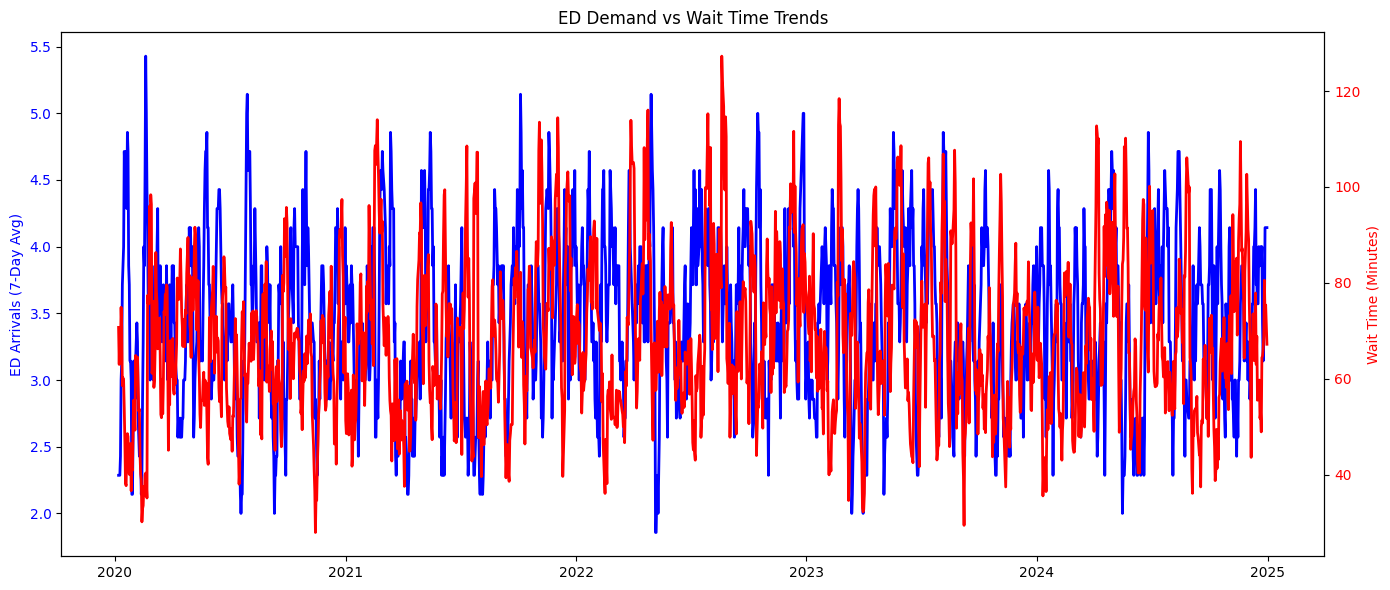

In [ ]:
# Visualisation
ed_daily["arrivals_7d"] = ed_daily["ed_arrivals"].rolling(7).mean()
ed_daily["wait_7d"] = ed_daily["avg_wait_time"].rolling(7).mean()

fig, ax1 = plt.subplots(figsize=(14,6))

# Left axis → ED arrivals
ax1.plot(
    ed_daily["arrival_date"],
    ed_daily["arrivals_7d"],
    color="blue",
    linewidth=2
)

ax1.set_ylabel(
    "ED Arrivals (7-Day Avg)",
    color="blue"
)

ax1.tick_params(
    axis="y",
    labelcolor="blue"
)

# Right axis → Wait time
ax2 = ax1.twinx()

ax2.plot(
    ed_daily["arrival_date"],
    ed_daily["wait_7d"],
    color="red",
    linewidth=2
)

ax2.set_ylabel(
    "Wait Time (Minutes)",
    color="red"
)

ax2.tick_params(
    axis="y",
    labelcolor="red"
)

plt.title("ED Demand vs Wait Time Trends")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

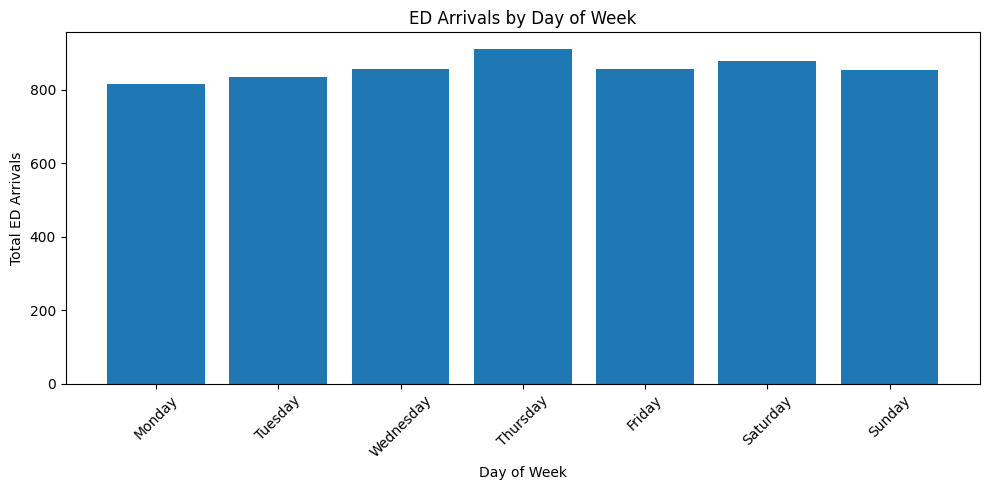

In [30]:
plt.figure(figsize=(10, 5))
plt.bar(demand_by_day["day_of_week"], demand_by_day["ed_arrivals"])
plt.title("ED Arrivals by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total ED Arrivals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


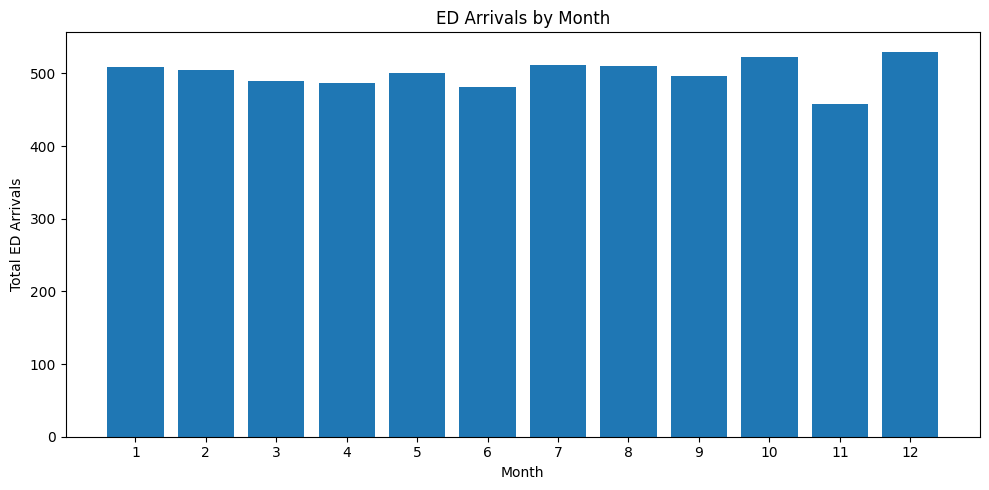

In [12]:
plt.figure(figsize=(10, 5))
plt.bar(demand_by_month["month"], demand_by_month["ed_arrivals"])
plt.title("ED Arrivals by Month")
plt.xlabel("Month")
plt.ylabel("Total ED Arrivals")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

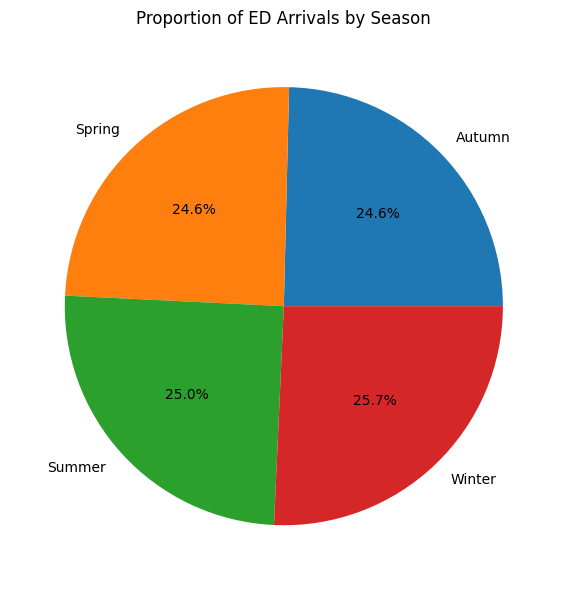

In [32]:
plt.figure(figsize=(7, 6))

plt.pie(
    demand_by_season["ed_arrivals"],
    labels=demand_by_season["season"],
    autopct="%1.1f%%"
)

plt.title("Proportion of ED Arrivals by Season")

plt.tight_layout()
plt.show()

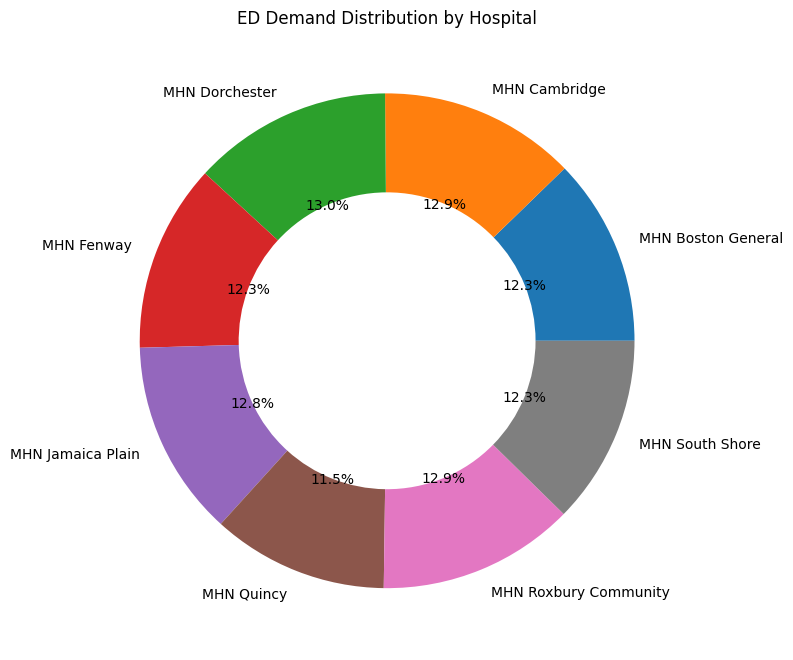

In [33]:
plt.figure(figsize=(8,8))

plt.pie(
    demand_by_hospital["ed_arrivals"],
    labels=demand_by_hospital["hospital"],
    autopct="%1.1f%%",
    wedgeprops={"width": 0.4}
)

plt.title("ED Demand Distribution by Hospital")

plt.tight_layout()
plt.show()

In [34]:
# Save datasets for forecasting
OUTPUT_HOURLY = BASE_DIR / "data" / "processed" / "ed_hourly_demand_investigation.csv"
OUTPUT_DAILY = BASE_DIR / "data" / "processed" / "ed_daily_demand_investigation.csv"

OUTPUT_HOURLY.parent.mkdir(parents=True, exist_ok=True)

ed_hourly.to_csv(OUTPUT_HOURLY, index=False)
ed_daily.to_csv(OUTPUT_DAILY, index=False)

print("Saved hourly file:", OUTPUT_HOURLY)
print("Saved daily file:", OUTPUT_DAILY)

Saved hourly file: c:\Users\lapto\OneDrive\Predictive Healthcare\Health-Care-predictive-Analysis\data\processed\ed_hourly_demand_investigation.csv
Saved daily file: c:\Users\lapto\OneDrive\Predictive Healthcare\Health-Care-predictive-Analysis\data\processed\ed_daily_demand_investigation.csv
